（1）confusion_matrix
混淆矩阵，用来统计：
真实 H0 预测成 H0 的数量
真实 H0 预测成 H1 的数量
真实 H1 预测成 H0 的数量
真实 H1 预测成 H1 的数量
（2）classification_report
生成分类报告，里面包括：
precision 精确率
recall 召回率
f1-score 
support 样本数量
（3）accuracy_score
计算准确率。
（4）f1_score
计算 F1-score，适合综合评价分类效果。
（5）roc_curve
计算 ROC 曲线，用于分析不同判决阈值下的检测性能。
（6）auc
计算 AUC 值，AUC 越接近 1，说明模型区分 H0/H1 的能力越强。

In [1]:
# ============================================================
# Cell 1: 安装与导入依赖
# ============================================================

# Kaggle 一般已经自带这些库，如果缺少再安装
!pip install pyts -q
!pip install h5py scikit-learn matplotlib seaborn torch scipy -q

import os
import json
import h5py
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import signal
from scipy.ndimage import zoom

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from pyts.image import RecurrencePlot

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    f1_score,
    roc_curve,
    auc
)

import warnings
warnings.filterwarnings("ignore")

# 固定随机种子，保证每次运行结果尽量一致
#1. 保证每次抽样数据尽量一致
#2. 保证训练结果尽量可复现
#3. 方便写实验报告和上传 GitHub
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# 自动选择 GPU 或 CPU
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ 当前使用设备: {DEVICE}")

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 27.9 MB/s eta 0:00:00
✅ 当前使用设备: cuda
GPU: Tesla T4


In [2]:
# ============================================================
# Cell 2: 读取 RadioML 2018.01A 的标签与 SNR
#
# 注意：
#   这里只读取 Y 和 Z，不读取 X。
#   X 数据很大，后面 Dataset 里按需读取，避免内存爆掉。
# ============================================================

HDF5_PATH = "/kaggle/input/datasets/pinxau1000/radioml2018/GOLD_XYZ_OSC.0001_1024.hdf5"

# RadioML 2018.01A 的调制类别顺序
MOD_CLASSES = [
    "OOK", "4ASK", "8ASK", "BPSK", "QPSK", "8PSK",
    "16PSK", "32PSK", "16APSK", "32APSK", "64APSK",
    "128APSK", "16QAM", "32QAM", "64QAM", "128QAM",
    "256QAM", "AM-SSB-WC", "AM-SSB-SC", "AM-DSB-WC",
    "AM-DSB-SC", "FM", "GMSK", "OQPSK"
]

print("📖 开始读取 Y 和 Z...")

with h5py.File(HDF5_PATH, "r") as f:
    # X 是 IQ 信号，暂时不读取
    # Y 是 one-hot 调制标签，shape 一般是 (N, 24)
    # Z 是 SNR 标签，shape 一般是 (N, 1)
    Y_raw = f["Y"][:]
    Z_raw = f["Z"][:]

# 将 one-hot 调制标签转成类别编号
y_mod_full = np.argmax(Y_raw, axis=1).astype(np.int32)

# 将 SNR 转成一维数组
snr_full = Z_raw.flatten().astype(np.int32)

# 释放原始数组，节省内存
del Y_raw, Z_raw

ALL_SNRS = sorted(np.unique(snr_full).tolist())

print("✅ 读取完成")
print(f"总样本数: {len(y_mod_full):,}")
print(f"调制类别数: {len(MOD_CLASSES)}")
print(f"SNR 档位: {ALL_SNRS}")

📖 开始读取 Y 和 Z...
✅ 读取完成
总样本数: 2,555,904
调制类别数: 24
SNR 档位: [-20, -18, -16, -14, -12, -10, -8, -6, -4, -2, 0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24, 26, 28, 30]


In [3]:
# ============================================================
# Cell 3: 分层均匀抽样
#
# 目的：
#   从完整 RadioML 2018.01A 中抽取一个较小但分布均匀的子集。
#
# 为什么要抽样？
#   完整数据集太大，直接做多模态图像转换会非常慢。
#   初版实验建议先跑通流程，再扩大数据量。
#
# 抽样方式：
#   每种调制方式抽取 SAMPLES_PER_MOD 条；
#   每种调制内部按 SNR 尽量均匀抽取。
# ============================================================

# 初版先用 3000，流程跑通后可以改成 10000
SAMPLES_PER_MOD = 10000

rng = np.random.default_rng(SEED)

selected_indices = []

print("📦 开始分层抽样...")

for mod_id, mod_name in enumerate(MOD_CLASSES):
    mod_indices_all = np.where(y_mod_full == mod_id)[0]
    
    per_snr = max(1, SAMPLES_PER_MOD // len(ALL_SNRS))
    chosen_for_mod = []
    
    for snr_db in ALL_SNRS:
        candidates = mod_indices_all[snr_full[mod_indices_all] == snr_db]
        
        if len(candidates) == 0:
            continue
        
        n_take = min(per_snr, len(candidates))
        chosen = rng.choice(candidates, size=n_take, replace=False)
        chosen_for_mod.extend(chosen.tolist())
    
    selected_indices.extend(chosen_for_mod)
    print(f"{mod_name:<12} 抽取 {len(chosen_for_mod):,} 条")

selected_indices = np.array(selected_indices, dtype=np.int64)

# 这些是抽样后的调制标签和 SNR 标签
# 注意：这里的 y_mod_sel / snr_sel 是 selected_indices 对应的子集标签
y_mod_sel = y_mod_full[selected_indices]
snr_sel   = snr_full[selected_indices]

print("\n✅ 分层抽样完成")
print(f"抽样总数: {len(selected_indices):,}")
print(f"y_mod_sel shape: {y_mod_sel.shape}")
print(f"snr_sel shape: {snr_sel.shape}")

📦 开始分层抽样...
OOK          抽取 9,984 条
4ASK         抽取 9,984 条
8ASK         抽取 9,984 条
BPSK         抽取 9,984 条
QPSK         抽取 9,984 条
8PSK         抽取 9,984 条
16PSK        抽取 9,984 条
32PSK        抽取 9,984 条
16APSK       抽取 9,984 条
32APSK       抽取 9,984 条
64APSK       抽取 9,984 条
128APSK      抽取 9,984 条
16QAM        抽取 9,984 条
32QAM        抽取 9,984 条
64QAM        抽取 9,984 条
128QAM       抽取 9,984 条
256QAM       抽取 9,984 条
AM-SSB-WC    抽取 9,984 条
AM-SSB-SC    抽取 9,984 条
AM-DSB-WC    抽取 9,984 条
AM-DSB-SC    抽取 9,984 条
FM           抽取 9,984 条
GMSK         抽取 9,984 条
OQPSK        抽取 9,984 条

✅ 分层抽样完成
抽样总数: 239,616
y_mod_sel shape: (239616,)
snr_sel shape: (239616,)


In [4]:
# ============================================================
# Cell 4: 定义已知/未知调制方式，以及训练/测试 SNR
#
# 频谱感知任务：
#   H1：存在主用户信号
#   H0：不存在主用户信号，或近似噪声类样本
#
# 测试集1：
#   已知调制 + 训练外 SNR，用于测试 SNR 泛化
#
# 测试集2：
#   未知调制 + 全 SNR，用于测试调制泛化
# ============================================================

# 训练中出现的已知调制方式
KNOWN_MODS = [
    "BPSK", "QPSK", "8PSK", "16PSK",
    "OOK", "4ASK", "8ASK",
    "16QAM", "32QAM", "64QAM",
    "AM-DSB-SC", "AM-SSB-SC",
    "GMSK", "OQPSK"
]

# 训练中不出现，只在测试集中使用的未知调制方式
UNKNOWN_MODS = [
    m for m in MOD_CLASSES if m not in KNOWN_MODS
]

known_idx = np.array([MOD_CLASSES.index(m) for m in KNOWN_MODS], dtype=np.int32)
unknown_idx = np.array([MOD_CLASSES.index(m) for m in UNKNOWN_MODS], dtype=np.int32)

# H0_data 使用极低 SNR 样本，作为近似无信号/困难负样本
H0_SNR = -20

# H1 训练 SNR：中等范围
TRAIN_H1_SNRS = [-10, -8, -6, -4, -2, 0, 2, 4, 6, 8, 10]

# 测试集1：已知调制，但使用训练外 SNR
TEST1_H1_SNRS = [
    s for s in ALL_SNRS
    if s not in TRAIN_H1_SNRS and s != H0_SNR
]

# 测试集2：未知调制，除 -20 dB 外都作为 H1
TEST2_H1_SNRS = [
    s for s in ALL_SNRS
    if s != H0_SNR
]

print("✅ 调制与 SNR 划分完成")
print(f"已知调制: {KNOWN_MODS}")
print(f"未知调制: {UNKNOWN_MODS}")
print(f"训练 H1 SNR: {TRAIN_H1_SNRS}")
print(f"测试集1 H1 SNR: {TEST1_H1_SNRS}")
print(f"测试集2 H1 SNR: {TEST2_H1_SNRS}")

✅ 调制与 SNR 划分完成
已知调制: ['BPSK', 'QPSK', '8PSK', '16PSK', 'OOK', '4ASK', '8ASK', '16QAM', '32QAM', '64QAM', 'AM-DSB-SC', 'AM-SSB-SC', 'GMSK', 'OQPSK']
未知调制: ['32PSK', '16APSK', '32APSK', '64APSK', '128APSK', '128QAM', '256QAM', 'AM-SSB-WC', 'AM-DSB-WC', 'FM']
训练 H1 SNR: [-10, -8, -6, -4, -2, 0, 2, 4, 6, 8, 10]
测试集1 H1 SNR: [-18, -16, -14, -12, 12, 14, 16, 18, 20, 22, 24, 26, 28, 30]
测试集2 H1 SNR: [-18, -16, -14, -12, -10, -8, -6, -4, -2, 0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24, 26, 28, 30]


In [5]:
# ============================================================
# Cell 5: 构建三阶段数据集索引
#
# 数据集结构：
#   训练集:
#       H1      = 已知调制 + 训练 SNR
#       H0_data = 已知调制 + SNR=-20dB
#       H0_awgn = 人工生成 AWGN
#
#   验证集:
#       与训练集同分布，按 80/20 划分
#
#   测试集1:
#       H1      = 已知调制 + 训练外 SNR
#       H0      = AWGN
#       目的：测试 SNR 泛化能力
#
#   测试集2:
#       H1      = 未知调制 + 全 SNR
#       H0_data = 未知调制 + SNR=-20dB
#       H0_awgn = AWGN
#       目的：测试调制泛化能力
# ============================================================

def get_mask(y_arr, snr_arr, mod_indices, snr_list):
    """
    根据调制方式和 SNR 条件筛选样本。
    返回 True/False 掩码。
    """
    return np.isin(y_arr, mod_indices) & np.isin(snr_arr, snr_list)


def generate_awgn(n_samples, snr_db_list, n_points=1024):
    """
    生成纯 AWGN 噪声样本，作为 H0 样本。

    输出 shape:
        (n_samples, 1024, 2)

    其中最后一维 2 表示 I/Q 两路。
    """
    if n_samples <= 0:
        return np.empty((0, n_points, 2), dtype=np.float32)

    per_snr = max(1, n_samples // len(snr_db_list))
    chunks = []

    for snr_db in snr_db_list:
        snr_lin = 10 ** (snr_db / 10.0)
        sigma = 1.0 / np.sqrt(2.0 * snr_lin)

        noise = np.random.randn(per_snr, n_points, 2).astype(np.float32) * sigma
        chunks.append(noise)

    arr = np.concatenate(chunks, axis=0)

    # 如果数量不足，则重复补足
    while len(arr) < n_samples:
        arr = np.concatenate([arr, arr], axis=0)

    return arr[:n_samples].astype(np.float32)


def shuffle_split80(arr):
    """
    先打乱，再按 80/20 划分。
    """
    arr = np.array(arr)
    rng.shuffle(arr)
    n_train = int(0.8 * len(arr))
    return arr[:n_train], arr[n_train:]


print("📦 构建训练/验证集...")

# -------------------------------
# 训练+验证 H1
# -------------------------------
mask_tv_h1 = get_mask(y_mod_sel, snr_sel, known_idx, TRAIN_H1_SNRS)
tv_h1_pos = np.where(mask_tv_h1)[0]
n_h1_tv = len(tv_h1_pos)

# -------------------------------
# 训练+验证 H0_data
# -------------------------------
mask_tv_h0d = get_mask(y_mod_sel, snr_sel, known_idx, [H0_SNR])
tv_h0d_pos = np.where(mask_tv_h0d)[0]
n_h0d_tv = len(tv_h0d_pos)

# -------------------------------
# 训练+验证 H0_awgn
# 让 H0 总量大致等于 H1 总量
# -------------------------------
n_awgn_tv_need = max(0, n_h1_tv - n_h0d_tv)
awgn_tv = generate_awgn(n_awgn_tv_need, TRAIN_H1_SNRS)

# 如果 H1 比 H0 多，就下采样 H1
n_h0_tv = n_h0d_tv + len(awgn_tv)
n_final_tv = min(n_h1_tv, n_h0_tv)

if n_final_tv < n_h1_tv:
    tv_h1_pos = rng.choice(tv_h1_pos, size=n_final_tv, replace=False)

# 训练/验证划分
train_h1_pos, val_h1_pos = shuffle_split80(tv_h1_pos)
train_h0d_pos, val_h0d_pos = shuffle_split80(tv_h0d_pos)

# AWGN 也打乱后划分
rng.shuffle(awgn_tv)
n_awgn_train = int(0.8 * len(awgn_tv))
train_awgn = awgn_tv[:n_awgn_train]
val_awgn = awgn_tv[n_awgn_train:]

print(f"训练集: H1={len(train_h1_pos):,}, H0_data={len(train_h0d_pos):,}, H0_awgn={len(train_awgn):,}")
print(f"验证集: H1={len(val_h1_pos):,}, H0_data={len(val_h0d_pos):,}, H0_awgn={len(val_awgn):,}")

# ============================================================
# 测试集1：SNR 泛化
# ============================================================

print("\n📦 构建测试集1：SNR 泛化...")

mask_t1_h1 = get_mask(y_mod_sel, snr_sel, known_idx, TEST1_H1_SNRS)
t1_h1_pos = np.where(mask_t1_h1)[0]
n_t1_h1 = len(t1_h1_pos)

# H0 全部用 AWGN，数量与 H1 相同
awgn_t1 = generate_awgn(n_t1_h1, TEST1_H1_SNRS)

# 保存 H1 的 SNR 信息，后面可用于 Pd-SNR 分析
snr_t1_h1 = snr_sel[t1_h1_pos]

print(f"测试集1: H1={len(t1_h1_pos):,}, H0_awgn={len(awgn_t1):,}")

# ============================================================
# 测试集2：调制泛化
# ============================================================

print("\n📦 构建测试集2：调制泛化...")

mask_t2_h1 = get_mask(y_mod_sel, snr_sel, unknown_idx, TEST2_H1_SNRS)
t2_h1_pos = np.where(mask_t2_h1)[0]
n_t2_h1 = len(t2_h1_pos)

mask_t2_h0d = get_mask(y_mod_sel, snr_sel, unknown_idx, [H0_SNR])
t2_h0d_pos = np.where(mask_t2_h0d)[0]
n_h0d_t2 = len(t2_h0d_pos)

n_awgn_t2_need = max(0, n_t2_h1 - n_h0d_t2)
awgn_t2 = generate_awgn(n_awgn_t2_need, TEST2_H1_SNRS)

n_h0_t2 = n_h0d_t2 + len(awgn_t2)
n_t2_final = min(n_t2_h1, n_h0_t2)

if n_t2_final < n_t2_h1:
    t2_h1_pos = rng.choice(t2_h1_pos, size=n_t2_final, replace=False)

# 保存测试集2 H1 的细粒度信息
snr_t2_h1 = snr_sel[t2_h1_pos]
mod_t2_h1 = y_mod_sel[t2_h1_pos]

print(f"测试集2: H1={len(t2_h1_pos):,}, H0_data={len(t2_h0d_pos):,}, H0_awgn={len(awgn_t2):,}")

print("\n✅ 数据索引构建完成")

📦 构建训练/验证集...
训练集: H1=47,308, H0_data=4,300, H0_awgn=43,008
验证集: H1=11,828, H0_data=1,076, H0_awgn=10,752

📦 构建测试集1：SNR 泛化...
测试集1: H1=75,264, H0_awgn=75,264

📦 构建测试集2：调制泛化...
测试集2: H1=96,000, H0_data=3,840, H0_awgn=92,160

✅ 数据索引构建完成


In [6]:
# ============================================================
# Cell 6: 多模态图像转换函数
#
# 保留三个模态：
#   1. STFT log-power 图：时频能量分布
#   2. GASF 图：全局时序相关性
#   3. RP 图：递归/重复结构
#
# 最终输出：
#   x_multi.shape = (3, 64, 64)
#
# 这一步是简单拼接：
#   第 0 通道：STFT
#   第 1 通道：GASF
#   第 2 通道：RP
# ============================================================

IMG_SIZE = 64


def normalize_01(img):
    """
    将二维图像归一化到 [0, 1]。
    不同模态数值范围不同，统一归一化后更适合 CNN 输入。
    """
    img = img.astype(np.float32)
    min_v = img.min()
    max_v = img.max()

    if max_v - min_v < 1e-8:
        return np.zeros_like(img, dtype=np.float32)

    return (img - min_v) / (max_v - min_v + 1e-8)


def resize_2d(img, size=64):
    """
    将任意二维图像缩放到 size × size。
    STFT 的输出尺寸不一定是 64×64，所以需要统一尺寸。
    """
    img = np.asarray(img, dtype=np.float32)

    h, w = img.shape
    zoom_h = size / h
    zoom_w = size / w

    out = zoom(img, (zoom_h, zoom_w), order=1)

    # 防止由于浮点缩放造成尺寸略有偏差
    out = out[:size, :size]

    if out.shape[0] < size or out.shape[1] < size:
        pad_h = size - out.shape[0]
        pad_w = size - out.shape[1]
        out = np.pad(out, ((0, pad_h), (0, pad_w)), mode="edge")

    return out.astype(np.float32)


def downsample_1d(x, size=64):
    """
    将一维序列从 1024 点压缩到 64 点。
    这样 GASF 和 RP 不会生成 1024×1024 的巨大图像。
    """
    x = np.asarray(x, dtype=np.float32)
    idx = np.linspace(0, len(x) - 1, size).astype(np.int32)
    return x[idx]


def make_stft_img(x, size=64):
    """
    构造 STFT log-power 图。

    【输入】
        x: (1024, 2)
           第 0 列是 I 路信号
           第 1 列是 Q 路信号

    【输出】
        img: (64, 64)

    【原理说明】
    无线电 IQ 信号可以表示为：
        s(t) = I(t) + jQ(t)

    STFT（短时傅里叶变换）会将信号分成多个短时间窗口，
    并对每个窗口分别做傅里叶变换，从而得到信号的时频分布。

    其中：
        magnitude = |Zxx|        表示幅度谱
        power = |Zxx|^2          表示功率谱
        log_power = 10log10(power) 表示 dB 形式的功率谱

    dB 压缩可以减小数值动态范围，使弱能量区域也更容易被模型学习。
    """

    # 提取单条数据的 I/Q 通道
    I = x[:, 0]
    Q = x[:, 1]

    # 构造复数信号 I + jQ
    complex_signal = I + 1j * Q

    # 设置归一化采样率
    # fs=1.0 表示这里的频率轴不是实际 Hz，而是归一化频率
    fs = 1.0

    # 计算 STFT
    # nperseg=64 表示每个窗口包含 64 个采样点
    # noverlap=32 表示相邻窗口重叠 32 个采样点
    f, t, Zxx = signal.stft(
        complex_signal,
        fs=fs,
        nperseg=64,
        noverlap=32,
        boundary=None
    )

    # 提取幅度谱
    magnitude = np.abs(Zxx)

    # 提取功率谱
    power = magnitude ** 2

    # 转换为 dB 功率谱
    # 加 1e-10 是为了避免 log10(0)
    log_power = 10 * np.log10(power + 1e-10)

    # 归一化到 [0, 1]
    img = normalize_01(log_power)

    # 统一缩放到 size × size
    img = resize_2d(img, size)

    return img.astype(np.float32)


from pyts.image import GramianAngularField

def make_gasf_img(x, size=64):
    """
    构造 GASF 图（Gramian Angular Summation Field）。

    【输入】
        x: (1024, 2)
           第 0 列是 I 路信号
           第 1 列是 Q 路信号

    【输出】
        img: (64, 64)

    【原理说明】
    1. 先由 IQ 两路构造幅度序列：
           amp = sqrt(I^2 + Q^2)
       幅度序列反映信号在各时刻的能量变化。

    2. 再将一维序列缩放到 [-1, 1] 区间，
       以便进行极坐标变换：
           phi_i = arccos(x_i)

    3. GASF 的核心公式为：
           G_ij = cos(phi_i + phi_j)

       它可以在保留时间顺序信息的同时，
       刻画任意两个时间点之间的全局相关性。

    4. 最终输出一个二维图像，可作为 CNN 的输入。
    """

    # 提取 I/Q 通道
    I = x[:, 0]
    Q = x[:, 1]

    # 构造幅度序列
    amplitude = np.sqrt(I ** 2 + Q ** 2)

    # 降采样到 size 个点
    amplitude = downsample_1d(amplitude, size)

    # pyts 需要输入形状为 (n_samples, n_timestamps)
    data_reshaped = amplitude.reshape(1, -1)

    # 构造 GASF 变换器
    gasf = GramianAngularField(method='summation', image_size=size)

    # 生成 GASF 图
    img_gasf = gasf.fit_transform(data_reshaped)

    # 取出第 0 个样本，对应形状为 (size, size)
    img = img_gasf[0]

    # 再做一次归一化到 [0, 1]，便于后续 CNN 输入
    img = normalize_01(img)

    return img.astype(np.float32)


def make_rp_img(x, size=64, percentage=20):
    """
    构造 RP 递归图（Recurrence Plot）。

    【输入】
        x: (1024, 2)
           第 0 列是 I 路信号
           第 1 列是 Q 路信号

    【输出】
        img: (64, 64)

    【原理说明】
    1. 先由 IQ 两路构造幅度序列：
           amp = sqrt(I^2 + Q^2)
       幅度序列反映信号在各时刻的能量变化。

    2. RP 的核心思想是比较任意两个时间点的状态是否足够接近。
       若两个时间点的距离小于阈值，则认为发生“递归”。

    3. RP 的定义公式为：
           R_{i,j} = Θ(ε - ||x_i - x_j||)
       其中：
           Θ   表示阶跃函数
           ε   表示阈值
           ||x_i - x_j|| 表示两个时间点状态之间的距离

    4. 在图像中：
       - 若第 i 个点和第 j 个点状态接近，则对应位置取 1
       - 否则取 0

    5. RP 能够反映时间序列中的重复结构、周期特征和动态模式。
    """

    # 提取 I/Q 通道
    I = x[:, 0]
    Q = x[:, 1]

    # 构造幅度序列
    amplitude = np.sqrt(I ** 2 + Q ** 2)

    # 降采样到 size 个点
    amplitude = downsample_1d(amplitude, size)

    # pyts 需要输入形状为 (n_samples, n_timestamps)
    data_reshaped = amplitude.reshape(1, -1)

    # 构造二值化 RP
    # threshold='point' 表示按距离点的分位数选阈值
    # percentage=20 表示选取下 20% 的距离作为递归点
    rp_binary = RecurrencePlot(threshold='point', percentage=percentage)

    # 生成 RP 图
    img_rp = rp_binary.transform(data_reshaped)

    # 取出第 0 个样本
    img = img_rp[0]

    # 转成 float32
    return img.astype(np.float32)


def iq_to_multimodal_img(x, size=64):
    """
    将一条 IQ 样本转换为三通道多模态图像。

    输入:
        x: (1024, 2)

    输出:
        x_multi: (3, 64, 64)
    """
    stft_img = make_stft_img(x, size)
    gasf_img = make_gasf_img(x, size)
    rp_img   = make_rp_img(x, size)

    # 简单拼接：按通道维度堆叠
    x_multi = np.stack([stft_img, gasf_img, rp_img], axis=0)

    return x_multi.astype(np.float32)

In [7]:
# ============================================================
# Cell 7: 多模态 Dataset
#
# 与讲义中的 Dataset 逻辑一致：
#   1. HDF5 样本按索引延迟读取
#   2. AWGN 样本直接从内存读取
#   3. 统一 IQ 形状为 (1024, 2)
#   4. 做功率归一化
#   5. 转换成多模态图像 (3, 64, 64)
# ============================================================

class SpectrumMultiModalDataset(Dataset):
    def __init__(self, hdf5_path, hdf5_positions, hdf5_labels,
                 awgn_data, selected_indices, img_size=64):
        """
        hdf5_path:
            RadioML HDF5 文件路径

        hdf5_positions:
            当前数据集要用的 HDF5 样本在抽样子集中的位置

        hdf5_labels:
            HDF5 样本对应的 H0/H1 标签

        awgn_data:
            人工生成的 AWGN 样本，shape = (M, 1024, 2)

        selected_indices:
            抽样子集位置到原始 HDF5 行号的映射
        """
        self.hdf5_path = hdf5_path

        # 将抽样子集中的位置映射回原始 HDF5 文件真实行号
        self.hdf5_rows = selected_indices[hdf5_positions].astype(np.int64)

        # HDF5 样本标签，顺序必须与 hdf5_positions 一致
        self.hdf5_labels = np.array(hdf5_labels, dtype=np.int64)

        # AWGN 数据直接存在内存中，标签全部为 0
        self.awgn_data = awgn_data.astype(np.float32)
        self.awgn_labels = np.zeros(len(awgn_data), dtype=np.int64)

        self.n_hdf5 = len(self.hdf5_rows)
        self.n_awgn = len(self.awgn_data)
        self.total = self.n_hdf5 + self.n_awgn

        self.img_size = img_size

        # HDF5 文件句柄，先不打开，真正读取时再打开
        self._f = None

    def _open(self):
        """
        延迟打开 HDF5 文件。
        """
        if self._f is None:
            self._f = h5py.File(self.hdf5_path, "r")

    def __len__(self):
        return self.total

    def _fix_shape(self, x):
        """
        将不同可能格式的 IQ 数据统一成 (1024, 2)。
        """
        x = np.asarray(x)

        if x.shape == (1024, 2):
            return x.astype(np.float32)

        if x.shape == (2, 1024):
            return x.transpose(1, 0).astype(np.float32)

        # 如果出现其他形状，但元素总数为 2048，则强制 reshape
        if x.size == 2048:
            return x.reshape(1024, 2).astype(np.float32)

        raise ValueError(f"无法识别的 IQ 形状: {x.shape}")

    def _power_normalize(self, x):
        """
        对 IQ 样本做功率归一化。

        归一化后，模型不容易只靠能量大小判断 H0/H1，
        而会更多学习 STFT/GASF/RP 中的结构特征。
        """
        power = float(np.mean(np.sum(x ** 2, axis=1))) + 1e-8
        x = x / np.sqrt(power)
        return x.astype(np.float32)

    def __getitem__(self, idx):
        """
        返回:
            x_multi: torch.Tensor, shape = (3, 64, 64)
            y:       torch.Tensor, 0 或 1
        """
        if idx < self.n_hdf5:
            # HDF5 样本
            self._open()
            row = int(self.hdf5_rows[idx])
            x = self._f["X"][row]
            y = int(self.hdf5_labels[idx])
        else:
            # AWGN 样本
            ai = idx - self.n_hdf5
            x = self.awgn_data[ai]
            y = int(self.awgn_labels[ai])

        # 统一形状
        x = self._fix_shape(x)

        # 功率归一化
        x = self._power_normalize(x)

        # 转换为多模态图像
        x_multi = iq_to_multimodal_img(x, self.img_size)

        return torch.from_numpy(x_multi), torch.tensor(y, dtype=torch.long)

    def __del__(self):
        """
        对象销毁时关闭 HDF5 文件。
        """
        if self._f is not None:
            try:
                self._f.close()
            except:
                pass

In [8]:
# ============================================================
# Cell 8: 创建 Dataset 和 DataLoader
# ============================================================

# 训练集
train_ds = SpectrumMultiModalDataset(
    hdf5_path=HDF5_PATH,
    hdf5_positions=np.concatenate([train_h1_pos, train_h0d_pos]),
    hdf5_labels=np.concatenate([
        np.ones(len(train_h1_pos), dtype=np.int64),
        np.zeros(len(train_h0d_pos), dtype=np.int64)
    ]),
    awgn_data=train_awgn,
    selected_indices=selected_indices,
    img_size=IMG_SIZE
)

# 验证集
val_ds = SpectrumMultiModalDataset(
    hdf5_path=HDF5_PATH,
    hdf5_positions=np.concatenate([val_h1_pos, val_h0d_pos]),
    hdf5_labels=np.concatenate([
        np.ones(len(val_h1_pos), dtype=np.int64),
        np.zeros(len(val_h0d_pos), dtype=np.int64)
    ]),
    awgn_data=val_awgn,
    selected_indices=selected_indices,
    img_size=IMG_SIZE
)

# 测试集1：H1 来自 HDF5，H0 全部为 AWGN
test1_ds = SpectrumMultiModalDataset(
    hdf5_path=HDF5_PATH,
    hdf5_positions=t1_h1_pos,
    hdf5_labels=np.ones(len(t1_h1_pos), dtype=np.int64),
    awgn_data=awgn_t1,
    selected_indices=selected_indices,
    img_size=IMG_SIZE
)

# 测试集2：H1 来自未知调制，H0 包含未知调制低 SNR + AWGN
test2_ds = SpectrumMultiModalDataset(
    hdf5_path=HDF5_PATH,
    hdf5_positions=np.concatenate([t2_h1_pos, t2_h0d_pos]),
    hdf5_labels=np.concatenate([
        np.ones(len(t2_h1_pos), dtype=np.int64),
        np.zeros(len(t2_h0d_pos), dtype=np.int64)
    ]),
    awgn_data=awgn_t2,
    selected_indices=selected_indices,
    img_size=IMG_SIZE
)

BATCH_SIZE = 256

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=(DEVICE.type == "cuda")
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=(DEVICE.type == "cuda")
)

test1_loader = DataLoader(
    test1_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=(DEVICE.type == "cuda")
)

test2_loader = DataLoader(
    test2_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=(DEVICE.type == "cuda")
)

print("✅ DataLoader 构建完成")
print(f"训练集样本数: {len(train_ds):,}")
print(f"验证集样本数: {len(val_ds):,}")
print(f"测试集1样本数: {len(test1_ds):,}")
print(f"测试集2样本数: {len(test2_ds):,}")

# 快速检查一个 batch 的形状
xb, yb = next(iter(train_loader))
print(f"\n一个 batch 的输入形状: {xb.shape}")
print(f"一个 batch 的标签形状: {yb.shape}")
print("期望输入形状应为: (B, 3, 64, 64)")

✅ DataLoader 构建完成
训练集样本数: 94,616
验证集样本数: 23,656
测试集1样本数: 150,528
测试集2样本数: 192,000

一个 batch 的输入形状: torch.Size([256, 3, 64, 64])
一个 batch 的标签形状: torch.Size([256])
期望输入形状应为: (B, 3, 64, 64)


In [9]:
# ============================================================
# Cell 9: 简单 2D CNN 频谱感知分类器
#
# 输入:
#   (B, 3, 64, 64)
#
# 其中:
#   3 个通道分别是 STFT、GASF、RP
#
# 输出:
#   (B, 2)
#   第 0 维表示 H0 得分
#   第 1 维表示 H1 得分
# ============================================================

class Simple2DCNN(nn.Module):
    def __init__(self, in_channels=3, num_classes=2, dropout=0.3):
        super().__init__()

        # 特征提取部分
        self.features = nn.Sequential(
            # 输入: (B, 3, 64, 64)
            nn.Conv2d(in_channels, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            # 输出: (B, 32, 32, 32)

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            # 输出: (B, 64, 16, 16)

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            # 输出: (B, 128, 8, 8)

            # 全局平均池化，将每张 8×8 特征图压缩成 1×1
            nn.AdaptiveAvgPool2d((1, 1))
            # 输出: (B, 128, 1, 1)
        )

        # 分类头
        self.classifier = nn.Sequential(
            nn.Flatten(),
            # 输出: (B, 128)

            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(64, num_classes)
            # 输出: (B, 2)
        )

    def forward(self, x):
        """
        前向传播：
            多模态图像 → CNN 特征提取 → 分类器 → H0/H1 logits
        """
        feat = self.features(x)
        logits = self.classifier(feat)
        return logits


model = Simple2DCNN(
    in_channels=3,
    num_classes=2,
    dropout=0.3
).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())

print(model)
print(f"\n✅ 模型总参数量: {total_params:,}")

Simple2DCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): AdaptiveAvgPool2d(output_size=(1, 1))
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=128, out_feature

In [10]:
# ============================================================
# Cell 10: 训练循环
# ============================================================

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2
)


def run_epoch(model, loader, criterion, optimizer, device, train=True):
    """
    运行一个 epoch。

    train=True:
        训练模式，执行反向传播和参数更新

    train=False:
        验证模式，只前向推理，不更新参数
    """
    if train:
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    total_correct = 0
    total_n = 0

    ctx = torch.enable_grad() if train else torch.no_grad()

    with ctx:
        for xb, yb in loader:
            xb = xb.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True)

            if train:
                optimizer.zero_grad()

            logits = model(xb)
            loss = criterion(logits, yb)

            if train:
                loss.backward()

                # 梯度裁剪，防止训练不稳定
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)

                optimizer.step()

            preds = logits.argmax(dim=1)

            total_correct += (preds == yb).sum().item()
            total_loss += loss.item() * len(yb)
            total_n += len(yb)

    avg_loss = total_loss / total_n
    avg_acc = total_correct / total_n

    return avg_loss, avg_acc


NUM_EPOCHS = 20

history = {
    "tr_loss": [],
    "val_loss": [],
    "tr_acc": [],
    "val_acc": []
}

best_val_loss = float("inf")
best_state = None

print(f"🚀 开始训练，共 {NUM_EPOCHS} 个 epoch\n")
print(f'{"Ep":>4}|{"TrLoss":>9}|{"TrAcc":>8}|{"ValLoss":>9}|{"ValAcc":>8}|{"LR":>9}')
print("-" * 55)

for ep in range(1, NUM_EPOCHS + 1):
    tr_l, tr_a = run_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        DEVICE,
        train=True
    )

    vl_l, vl_a = run_epoch(
        model,
        val_loader,
        criterion,
        optimizer,
        DEVICE,
        train=False
    )

    scheduler.step(vl_l)

    history["tr_loss"].append(tr_l)
    history["val_loss"].append(vl_l)
    history["tr_acc"].append(tr_a)
    history["val_acc"].append(vl_a)

    if vl_l < best_val_loss:
        best_val_loss = vl_l
        best_state = {
            k: v.detach().cpu().clone()
            for k, v in model.state_dict().items()
        }

    lr = optimizer.param_groups[0]["lr"]

    print(f"{ep:>4}|{tr_l:>9.4f}|{tr_a:>7.2%}|{vl_l:>9.4f}|{vl_a:>7.2%}|{lr:>9.2e}")

# 加载验证集表现最好的模型
model.load_state_dict(best_state)
model.to(DEVICE)

print(f"\n🏆 最优验证损失: {best_val_loss:.4f}")

🚀 开始训练，共 20 个 epoch

  Ep|   TrLoss|   TrAcc|  ValLoss|  ValAcc|       LR
-------------------------------------------------------
   1|   0.2630| 89.30%|   0.2532| 88.93%| 1.00e-03
   2|   0.1952| 92.64%|   0.2021| 92.44%| 1.00e-03
   3|   0.1883| 92.90%|   0.2338| 91.66%| 1.00e-03
   4|   0.1847| 93.13%|   0.2620| 90.83%| 1.00e-03
   5|   0.1804| 93.20%|   0.1780| 93.37%| 1.00e-03
   6|   0.1785| 93.39%|   0.1921| 92.64%| 1.00e-03
   7|   0.1765| 93.45%|   0.1802| 93.35%| 1.00e-03
   8|   0.1740| 93.50%|   0.2371| 91.96%| 5.00e-04
   9|   0.1652| 93.89%|   0.2961| 87.22%| 5.00e-04
  10|   0.1648| 93.95%|   0.1777| 93.41%| 5.00e-04
  11|   0.1626| 93.95%|   0.1984| 92.82%| 5.00e-04
  12|   0.1587| 94.20%|   0.2997| 90.75%| 5.00e-04
  13|   0.1558| 94.36%|   0.4655| 80.21%| 2.50e-04
  14|   0.1450| 94.87%|   0.1901| 92.92%| 2.50e-04
  15|   0.1423| 94.90%|   0.2717| 91.54%| 2.50e-04
  16|   0.1362| 95.21%|   0.2600| 89.41%| 1.25e-04
  17|   0.1282| 95.64%|   0.1921| 93.05%| 1.25e-04
  1

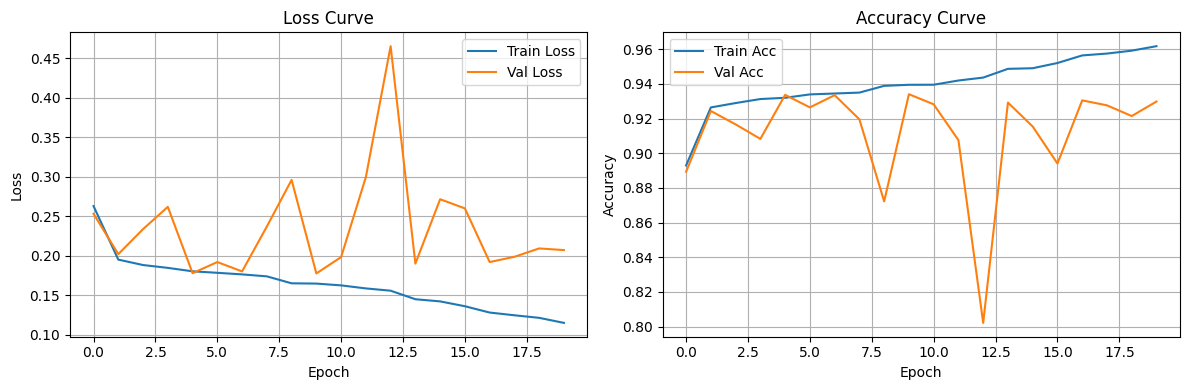

In [11]:
# ============================================================
# Cell 11: 训练曲线可视化
# ============================================================

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history["tr_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history["tr_acc"], label="Train Acc")
plt.plot(history["val_acc"], label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Curve")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [12]:
# ============================================================
# Cell 12: 推理与评估
#
# 指标：
#   Acc  : 准确率
#   F1   : F1-score
#   Pd   : 检测概率，H1 被正确检测为 H1 的比例
#   Pfa  : 虚警概率，H0 被误判为 H1 的比例
#   AUC  : ROC 曲线下面积
# ============================================================

def predict_dataset(model, loader, device):
    """
    对整个数据集进行预测。
    """
    model.eval()

    preds_all = []
    trues_all = []
    probs_all = []

    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device, non_blocking=True)

            logits = model(xb)
            probs = torch.softmax(logits, dim=1)

            preds = logits.argmax(dim=1).cpu().numpy()

            preds_all.extend(preds)
            trues_all.extend(yb.numpy())
            probs_all.extend(probs.cpu().numpy())

    return (
        np.array(preds_all),
        np.array(trues_all),
        np.array(probs_all)
    )


def full_metrics(y_true, y_pred, y_prob, name=""):
    """
    计算完整指标。
    """
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])

    TN, FP, FN, TP = cm.ravel()

    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    Pd = TP / (TP + FN + 1e-10)
    Pfa = FP / (FP + TN + 1e-10)

    prob_h1 = y_prob[:, 1]

    if len(np.unique(y_true)) == 2:
        fpr, tpr, _ = roc_curve(y_true, prob_h1)
        roc_auc = auc(fpr, tpr)
    else:
        roc_auc = np.nan

    print("=" * 60)
    print(f"📊 {name}")
    print("=" * 60)
    print(f"Accuracy : {acc:.4f}")
    print(f"F1-score : {f1:.4f}")
    print(f"Pd       : {Pd:.4f}")
    print(f"Pfa      : {Pfa:.4f}")
    print(f"AUC      : {roc_auc:.4f}")
    print("\nConfusion Matrix:")
    print(cm)
    print("\nClassification Report:")
    print(classification_report(
        y_true,
        y_pred,
        target_names=["H0", "H1"],
        digits=4,
        zero_division=0
    ))

    return {
        "acc": acc,
        "f1": f1,
        "Pd": Pd,
        "Pfa": Pfa,
        "auc": roc_auc,
        "cm": cm
    }


# 验证集
pred_v, true_v, prob_v = predict_dataset(model, val_loader, DEVICE)
m_v = full_metrics(true_v, pred_v, prob_v, name="Validation Set")

# 测试集1：SNR 泛化
pred_t1, true_t1, prob_t1 = predict_dataset(model, test1_loader, DEVICE)
m_t1 = full_metrics(true_t1, pred_t1, prob_t1, name="Test Set 1: SNR Generalization")

# 测试集2：调制泛化
pred_t2, true_t2, prob_t2 = predict_dataset(model, test2_loader, DEVICE)
m_t2 = full_metrics(true_t2, pred_t2, prob_t2, name="Test Set 2: Modulation Generalization")

📊 Validation Set
Accuracy : 0.9341
F1-score : 0.9314
Pd       : 0.8957
Pfa      : 0.0276
AUC      : 0.9714

Confusion Matrix:
[[11502   326]
 [ 1234 10594]]

Classification Report:
              precision    recall  f1-score   support

          H0     0.9031    0.9724    0.9365     11828
          H1     0.9701    0.8957    0.9314     11828

    accuracy                         0.9341     23656
   macro avg     0.9366    0.9341    0.9340     23656
weighted avg     0.9366    0.9341    0.9340     23656

📊 Test Set 1: SNR Generalization
Accuracy : 0.8494
F1-score : 0.8285
Pd       : 0.7273
Pfa      : 0.0285
AUC      : 0.8697

Confusion Matrix:
[[73121  2143]
 [20521 54743]]

Classification Report:
              precision    recall  f1-score   support

          H0     0.7809    0.9715    0.8658     75264
          H1     0.9623    0.7273    0.8285     75264

    accuracy                         0.8494    150528
   macro avg     0.8716    0.8494    0.8472    150528
weighted avg     0.8716

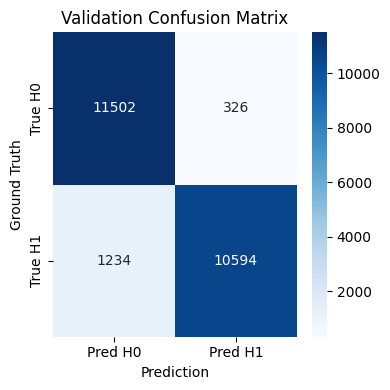

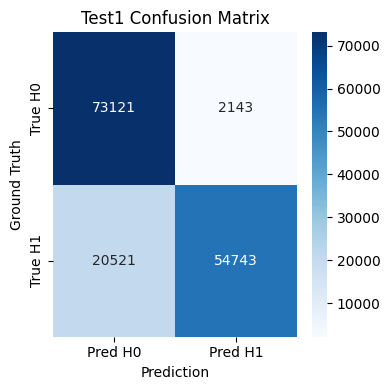

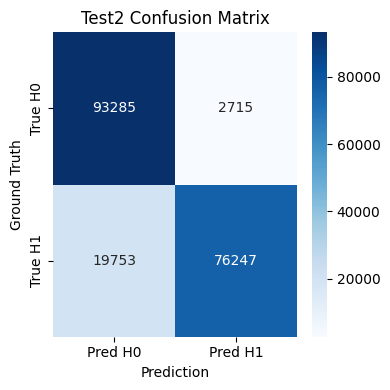

In [13]:
# ============================================================
# Cell 13: 混淆矩阵可视化
# ============================================================

def plot_cm(cm, title):
    plt.figure(figsize=(4, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Pred H0", "Pred H1"],
        yticklabels=["True H0", "True H1"]
    )
    plt.title(title)
    plt.xlabel("Prediction")
    plt.ylabel("Ground Truth")
    plt.tight_layout()
    plt.show()


plot_cm(m_v["cm"], "Validation Confusion Matrix")
plot_cm(m_t1["cm"], "Test1 Confusion Matrix")
plot_cm(m_t2["cm"], "Test2 Confusion Matrix")

In [14]:
# ============================================================
# Cell 14: 保存模型与实验结果
#
# 这些文件后续可以上传到 GitHub：
#   results/best_simple2dcnn_multimodal.pth
#   results/metrics_summary.json
# ============================================================

os.makedirs("results", exist_ok=True)

# 保存模型参数
model_path = "results/best_simple2dcnn_multimodal.pth"
torch.save(model.state_dict(), model_path)

# 保存实验指标
metrics_summary = {
    "Validation": {
        "acc": float(m_v["acc"]),
        "f1": float(m_v["f1"]),
        "Pd": float(m_v["Pd"]),
        "Pfa": float(m_v["Pfa"]),
        "auc": float(m_v["auc"])
    },
    "Test1_SNR_Generalization": {
        "acc": float(m_t1["acc"]),
        "f1": float(m_t1["f1"]),
        "Pd": float(m_t1["Pd"]),
        "Pfa": float(m_t1["Pfa"]),
        "auc": float(m_t1["auc"])
    },
    "Test2_Modulation_Generalization": {
        "acc": float(m_t2["acc"]),
        "f1": float(m_t2["f1"]),
        "Pd": float(m_t2["Pd"]),
        "Pfa": float(m_t2["Pfa"]),
        "auc": float(m_t2["auc"])
    }
}

metrics_path = "results/metrics_summary.json"

with open(metrics_path, "w", encoding="utf-8") as f:
    json.dump(metrics_summary, f, indent=4, ensure_ascii=False)

print("✅ 模型和实验结果已保存")
print(f"模型路径: {model_path}")
print(f"指标路径: {metrics_path}")

✅ 模型和实验结果已保存
模型路径: results/best_simple2dcnn_multimodal.pth
指标路径: results/metrics_summary.json


In [15]:
# ============================================================
# Cell 15: 最终实验总结
# ============================================================

print("=" * 80)
print("📌 基于 RadioML 2018.01A 的多模态频谱感知实验总结")
print("=" * 80)

print("""
本实验将 RadioML 2018.01A 原始调制识别数据集改造为 H0/H1 二分类频谱感知任务。

其中：
H1 表示存在主用户信号；
H0 表示纯 AWGN 噪声样本或极低 SNR 近似噪声样本。

在数据表示方面，本文没有直接使用原始 IQ 序列输入模型，
而是将每条 IQ 信号转换为三种二维模态图像：

1. STFT log-power 图：
   用于刻画信号的时频能量分布。

2. GASF 图：
   用于描述时间序列中不同时间点之间的全局相关性。

3. RP 递归图：
   用于反映序列状态的重复性和递归结构。

随后，将三种模态统一调整为 64×64，
并按通道维度简单拼接为 (3, 64, 64) 的多模态输入，
送入简单二维卷积神经网络进行 H0/H1 分类。

本实验设置了三个评估阶段：
1. Validation：验证模型在已知调制、训练 SNR 范围内的表现；
2. Test Set 1：测试已知调制下训练外 SNR 的泛化能力；
3. Test Set 2：测试未知调制方式下的调制泛化能力。
""")

summary_rows = [
    ["Validation", m_v["acc"], m_v["Pd"], m_v["Pfa"], m_v["auc"]],
    ["Test1 SNR Gen.", m_t1["acc"], m_t1["Pd"], m_t1["Pfa"], m_t1["auc"]],
    ["Test2 Mod Gen.", m_t2["acc"], m_t2["Pd"], m_t2["Pfa"], m_t2["auc"]]
]

print(f"{'Stage':<20} | {'Acc':>8} | {'Pd':>8} | {'Pfa':>8} | {'AUC':>8}")
print("-" * 65)

for row in summary_rows:
    print(f"{row[0]:<20} | {row[1]:>8.2%} | {row[2]:>8.2%} | {row[3]:>8.2%} | {row[4]:>8.4f}")

print("=" * 80)

📌 基于 RadioML 2018.01A 的多模态频谱感知实验总结

本实验将 RadioML 2018.01A 原始调制识别数据集改造为 H0/H1 二分类频谱感知任务。

其中：
H1 表示存在主用户信号；
H0 表示纯 AWGN 噪声样本或极低 SNR 近似噪声样本。

在数据表示方面，本文没有直接使用原始 IQ 序列输入模型，
而是将每条 IQ 信号转换为三种二维模态图像：

1. STFT log-power 图：
   用于刻画信号的时频能量分布。

2. GASF 图：
   用于描述时间序列中不同时间点之间的全局相关性。

3. RP 递归图：
   用于反映序列状态的重复性和递归结构。

随后，将三种模态统一调整为 64×64，
并按通道维度简单拼接为 (3, 64, 64) 的多模态输入，
送入简单二维卷积神经网络进行 H0/H1 分类。

本实验设置了三个评估阶段：
1. Validation：验证模型在已知调制、训练 SNR 范围内的表现；
2. Test Set 1：测试已知调制下训练外 SNR 的泛化能力；
3. Test Set 2：测试未知调制方式下的调制泛化能力。

Stage                |      Acc |       Pd |      Pfa |      AUC
-----------------------------------------------------------------
Validation           |   93.41% |   89.57% |    2.76% |   0.9714
Test1 SNR Gen.       |   84.94% |   72.73% |    2.85% |   0.8697
Test2 Mod Gen.       |   88.30% |   79.42% |    2.83% |   0.9124
